# Hong Kong Traffic Accident Severity Prediction
**Data Source:** Hong Kong Traffic Accident Datasets via the hkdatasets open-source repository. <br>
**Original Publisher:** Transport Department of the Hong Kong SAR Government.<br>
**Dataset Scope:** Comprehensive records of traffic accidents, casualties, and vehicles in Hong Kong.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score
from lightgbm import LGBMClassifier
from lightgbm import LGBMRegressor

In [2]:
df_accs = pd.read_csv(r"C:\Users\ivanl\OneDrive\文件\SDSC_2005\SDSC_pro\hk_accidents.csv")
df_cas = pd.read_csv(r"C:\Users\ivanl\OneDrive\文件\SDSC_2005\SDSC_pro\hk_casualties.csv")
df_vehs = pd.read_csv(r"C:\Users\ivanl\OneDrive\文件\SDSC_2005\SDSC_pro\hk_vehicles.csv")
df_accs = df_accs.drop(columns=['Grid_E', 'Grid_N', 'latitude', 'longitude'])

# Data cleaning
* Handled outliers, duplicated records and missing values.
* Executed relational multi-table joins

In [3]:
print("=== Accidents Info ===")
df_accs.info()

print("\n=== Casualties Info ===")
df_cas.info()

print("\n=== Vehicles Info ===")
df_vehs.info()

=== Accidents Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95821 entries, 0 to 95820
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   OBJECTID                   95821 non-null  int64 
 1   Year                       95821 non-null  int64 
 2   Serial_No_                 95821 non-null  int64 
 3   Severity                   95821 non-null  object
 4   District_Council_District  95821 non-null  object
 5   Hit_and_Run                95821 non-null  object
 6   Weather                    95821 non-null  object
 7   Rain                       95821 non-null  object
 8   Natural_Light              95821 non-null  object
 9   Junction_Control           95813 non-null  object
 10  Road_Classification        95812 non-null  object
 11  Vehicle_Movements          95821 non-null  object
 12  Type_of_Collision          95821 non-null  object
 13  No__of_Vehicles_Involved   95821 non-n

In [4]:
dfs = {'Accidents': df_accs, 'Casualties': df_cas, 'Vehicles': df_vehs}
for name, df in dfs.items():
    print(f"{name} : {df.duplicated().sum()}")
    print(f"{name} : {df.isnull().sum()}")

Accidents : 0
Accidents : OBJECTID                     0
Year                         0
Serial_No_                   0
Severity                     0
District_Council_District    0
Hit_and_Run                  0
Weather                      0
Rain                         0
Natural_Light                0
Junction_Control             8
Road_Classification          9
Vehicle_Movements            0
Type_of_Collision            0
No__of_Vehicles_Involved     0
No__of_Casualties_Injured    0
Date                         0
Time                         0
dtype: int64
Casualties : 0
Casualties : OBJECTID                               0
Year                                   0
Serial_No_                             0
Casualty_Age                           0
Casualty_Sex                           0
Degree_of_Injury                       0
Role_of_Casualty                       0
Location_of_Injury_Head                0
Location_of_Injury_Upper_trunk         0
Location_of_Injury_Lower_trunk       

In [5]:
df_cas['Vehicle_Class_of_Driver_or_Pass'] = df_cas['Vehicle_Class_of_Driver_or_Pass'].fillna('Not Applicable')
df_vehs['Year_of_Manufacture'] = df_vehs['Year_of_Manufacture'].fillna(df_vehs['Year_of_Manufacture'].median())
df_accs['Junction_Control'] = df_accs['Junction_Control'].fillna('Not known')
df_accs['Road_Classification'] = df_accs['Road_Classification'].fillna('Not known')

In [6]:
df_merged = pd.merge(df_accs, df_cas, on='Serial_No_', how='left')
df_final = pd.merge(df_merged, df_vehs, on='Serial_No_', how='left')
print(f"rows : {df_final.shape[0]}, columns : {df_final.shape[1]}")
print(df_final.columns.tolist())

rows : 208324, columns : 37
['OBJECTID_x', 'Year_x', 'Serial_No_', 'Severity', 'District_Council_District', 'Hit_and_Run', 'Weather', 'Rain', 'Natural_Light', 'Junction_Control', 'Road_Classification', 'Vehicle_Movements', 'Type_of_Collision', 'No__of_Vehicles_Involved', 'No__of_Casualties_Injured', 'Date', 'Time', 'OBJECTID_y', 'Year_y', 'Casualty_Age', 'Casualty_Sex', 'Degree_of_Injury', 'Role_of_Casualty', 'Location_of_Injury_Head', 'Location_of_Injury_Upper_trunk', 'Location_of_Injury_Lower_trunk', 'Location_of_Injury_Arms', 'Location_of_Injury_Legs', 'Pedestrian_Action', 'Vehicle_Class_of_Driver_or_Pass', 'OBJECTID', 'Year', 'Driver_Age', 'Driver_Sex', 'Year_of_Manufacture', 'Severity_of_Accident', 'Vehicle_Class']


In [7]:
df_final = df_final.drop(columns=['OBJECTID_y', 'Year_y','OBJECTID', 'Year'])
df_final = df_final.rename(columns={'OBJECTID_x':'OBJECT_ID', 'Year_x':'Years'})
print(df_final.columns.tolist())

['OBJECT_ID', 'Years', 'Serial_No_', 'Severity', 'District_Council_District', 'Hit_and_Run', 'Weather', 'Rain', 'Natural_Light', 'Junction_Control', 'Road_Classification', 'Vehicle_Movements', 'Type_of_Collision', 'No__of_Vehicles_Involved', 'No__of_Casualties_Injured', 'Date', 'Time', 'Casualty_Age', 'Casualty_Sex', 'Degree_of_Injury', 'Role_of_Casualty', 'Location_of_Injury_Head', 'Location_of_Injury_Upper_trunk', 'Location_of_Injury_Lower_trunk', 'Location_of_Injury_Arms', 'Location_of_Injury_Legs', 'Pedestrian_Action', 'Vehicle_Class_of_Driver_or_Pass', 'Driver_Age', 'Driver_Sex', 'Year_of_Manufacture', 'Severity_of_Accident', 'Vehicle_Class']


In [8]:
object_cols = df_final.select_dtypes(include=['object']).columns
for col in object_cols:
    print(f"Columns : {col}")
    print(df_final[col].value_counts(dropna=False))
    print("-" * 40)

Columns : Severity
Severity
Slight     174984
Serious     31198
Fatal        2142
Name: count, dtype: int64
----------------------------------------
Columns : District_Council_District
District_Council_District
YL     19590
YTM    18397
ST     17093
KT     15545
TW     13821
TP     13652
KC     13515
SSP    11631
KTS    11583
WCH     9856
N       9855
TM      9657
CW      9151
E       8539
WTS     8038
SK      7086
I       5794
S       5521
Name: count, dtype: int64
----------------------------------------
Columns : Hit_and_Run
Hit_and_Run
No     204727
Yes      3597
Name: count, dtype: int64
----------------------------------------
Columns : Weather
Weather
Clear          195041
Dull            10349
Fog/mist         2032
Strong wind       689
Not known         213
Name: count, dtype: int64
----------------------------------------
Columns : Rain
Rain
Not raining    181320
Light rain      22636
Heavy rain       3787
Not known         581
Name: count, dtype: int64
----------------------

In [9]:
df_final.describe()

,OBJECT_ID,Years,Serial_No_,No__of_Vehicles_Involved,No__of_Casualties_Injured,Time,Casualty_Age,Driver_Age,Year_of_Manufacture
count,208324.000000,208324.000000,208324.000000,208324.000000,208324.000000,208324.000000,208324.000000,208324.000000,208324.000000
mean,48475.597612,2016.524625,48475.354904,2.153156,2.568480,1385.209414,52.004363,64.585261,2008.486137
std,27723.262881,1.707994,27722.955258,1.174153,5.096727,569.607066,96.631723,134.146889,5.599081
min,1.000000,2014.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1962.000000
25%,24616.000000,2015.000000,24616.000000,2.000000,1.000000,950.000000,31.000000,35.000000,2004.000000
50%,48612.000000,2017.000000,48612.000000,2.000000,1.000000,1435.000000,42.000000,47.000000,2009.000000
75%,72581.000000,2018.000000,72581.000000,2.000000,2.000000,1830.000000,55.000000,57.000000,2013.000000
max,95821.000000,2019.000000,95821.000000,21.000000,77.000000,2359.000000,999.000000,999.000000,2019.000000


In [10]:
df_final.loc[df_final['Casualty_Age'] > 100, 'Casualty_Age'] = np.nan
df_final.loc[(df_final['Driver_Age'] < 15) | (df_final['Driver_Age'] > 85), 'Driver_Age'] = np.nan
df_final['Casualty_Age'] = df_final['Casualty_Age'].fillna(df_final['Casualty_Age'].median())
df_final['Driver_Age'] = df_final['Driver_Age'].fillna(df_final['Driver_Age'].median())
df_final[['Casualty_Age', 'Driver_Age']].describe()

,Casualty_Age,Driver_Age
count,208324.000000,208324.000000
mean,42.434266,45.807636
std,16.734253,13.127487
min,0.000000,15.000000
25%,31.000000,35.000000
50%,42.000000,46.000000
75%,55.000000,56.000000
max,100.000000,85.000000


# Feature Engineering: Time-Based Extraction
* Converted raw datetime strings into high-value structured features.<br>
* Grouped the 24-hour variable into 5 meaningful behavioral categories.

In [11]:
df_final['Date'] = pd.to_datetime(df_final['Date'])
df_final['Month'] = df_final['Date'].dt.month
df_final['Day_of_Week'] = df_final['Date'].dt.dayofweek
df_final['Is_Weekend'] = df_final['Day_of_Week'].isin([5, 6]).astype(int)
df_final['Hour'] = df_final['Time']//100

def time_slot(hour):
    if 5 <= hour < 11:
        return 'Morning'
    if 11 <= hour < 16:
        return 'Afternoon'
    if 16 <= hour < 18:
        return 'Evening'
    if 18 <= hour < 23:
        return 'Night'
    else: return 'Late_night'

df_final['Time_slot'] = df_final['Hour'].apply(time_slot)
df_final = df_final.drop(columns=['Date', 'Time'])
print(df_final[['Month','Is_Weekend','Time_slot']])


        Month  Is_Weekend   Time_slot
0           1           0  Late_night
1           1           0     Morning
2           1           0     Morning
3           1           0     Morning
4           1           0     Morning
...       ...         ...         ...
208319     11           0       Night
208320     12           1   Afternoon
208321     12           0   Afternoon
208322     12           1     Evening
208323     12           1     Morning

[208324 rows x 3 columns]


In [12]:
print(df_final.columns.tolist())

['OBJECT_ID', 'Years', 'Serial_No_', 'Severity', 'District_Council_District', 'Hit_and_Run', 'Weather', 'Rain', 'Natural_Light', 'Junction_Control', 'Road_Classification', 'Vehicle_Movements', 'Type_of_Collision', 'No__of_Vehicles_Involved', 'No__of_Casualties_Injured', 'Casualty_Age', 'Casualty_Sex', 'Degree_of_Injury', 'Role_of_Casualty', 'Location_of_Injury_Head', 'Location_of_Injury_Upper_trunk', 'Location_of_Injury_Lower_trunk', 'Location_of_Injury_Arms', 'Location_of_Injury_Legs', 'Pedestrian_Action', 'Vehicle_Class_of_Driver_or_Pass', 'Driver_Age', 'Driver_Sex', 'Year_of_Manufacture', 'Severity_of_Accident', 'Vehicle_Class', 'Month', 'Day_of_Week', 'Is_Weekend', 'Hour', 'Time_slot']


In [13]:
df_final = df_final.drop(columns=['Severity_of_Accident', 'OBJECT_ID', 'Years'])

In [14]:
print("Severity：", df_final['Severity'].unique())
print("Degree_of_Injury :", df_final['Degree_of_Injury'].unique())

Severity： ['Serious' 'Slight' 'Fatal']
Degree_of_Injury : ['Seriously Injured' 'Slightly Injured' 'Killed']


# Encoding

In [15]:
severity_mapping = {'Slight': 0, 'Serious': 1, 'Fatal': 2}
Degree_of_Injury_mapping = {'Slightly Injured': 0, 'Seriously Injured': 1, 'Killed': 2}

df_final['Severity'] = df_final['Severity'].map(severity_mapping)
df_final['Degree_of_Injury'] = df_final['Degree_of_Injury'].map(Degree_of_Injury_mapping)

In [16]:
cate_cols = df_final.select_dtypes(include=['object']).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[('practice', OneHotEncoder(drop='first', sparse_output=False), cate_cols)],
    remainder='passthrough')

X_encoded = preprocessor.fit_transform(df_final)
encoded_p_cols = preprocessor.named_transformers_['practice'].get_feature_names_out(cate_cols)
all_new_cols = list(encoded_p_cols) + [col for col in df_final.columns if col not in cate_cols]
df_encoded = pd.DataFrame(X_encoded, columns=all_new_cols).astype(int)
print(df_encoded.head(5))

   District_Council_District_E  District_Council_District_I  \
0                            1                            0   
1                            0                            0   
2                            0                            0   
3                            0                            0   
4                            0                            0   

   District_Council_District_KC  District_Council_District_KT  \
0                             0                             0   
1                             0                             0   
2                             0                             0   
3                             0                             0   
4                             0                             0   

   District_Council_District_KTS  District_Council_District_N  \
0                              0                            0   
1                              0                            0   
2                              0   

In [17]:
X = df_encoded.drop(columns=['Severity', 'Degree_of_Injury','No__of_Casualties_Injured', 'Serial_No_'])
y_injury = df_encoded['Degree_of_Injury']
X_train_inj, X_test_inj, y_train_inj, y_test_inj = train_test_split(
    X, y_injury, test_size=0.2, random_state=42, stratify=y_injury)

unique_ids = df_encoded['Serial_No_'].unique()   #Avoid Group Leakage: split by unique accident ID
np.random.seed(42)
np.random.shuffle(unique_ids)
train_ids = unique_ids[:int(len(unique_ids)*0.8)]

X_train_sev = df_encoded[df_encoded['Serial_No_'].isin(train_ids)].drop(columns=['Serial_No_', 'Severity', 'Degree_of_Injury','No__of_Casualties_Injured'])
y_train_sev = df_encoded[df_encoded['Serial_No_'].isin(train_ids)]['Severity']
X_test_sev = df_encoded[~df_encoded['Serial_No_'].isin(train_ids)].drop(columns=['Serial_No_', 'Severity', 'Degree_of_Injury','No__of_Casualties_Injured'])
y_test_sev = df_encoded[~df_encoded['Serial_No_'].isin(train_ids)]['Severity']

X_train_no_of_injured = df_encoded[df_encoded['Serial_No_'].isin(train_ids)].drop(columns=['Serial_No_', 'Severity', 'Degree_of_Injury','No__of_Casualties_Injured'])
y_train_no_of_injured = df_encoded[df_encoded['Serial_No_'].isin(train_ids)]['No__of_Casualties_Injured']
X_test_no_of_injured = df_encoded[~df_encoded['Serial_No_'].isin(train_ids)].drop(columns=['Serial_No_', 'Severity', 'Degree_of_Injury','No__of_Casualties_Injured'])
y_test_no_of_injured =df_encoded[~df_encoded['Serial_No_'].isin(train_ids)]['No__of_Casualties_Injured']

# Modeling (Severity)

In [18]:
model_sev = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_sev.fit(X_train_sev, y_train_sev)
y_pred_ran = model_sev.predict(X_test_sev)
print(classification_report(y_test_sev, y_pred_ran))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91     34494
           1       0.38      0.01      0.02      6456
           2       1.00      0.00      0.00       507

    accuracy                           0.83     41457
   macro avg       0.74      0.34      0.31     41457
weighted avg       0.76      0.83      0.76     41457



In [19]:
weight = {0 : 1, 1 : 4, 2 : 70}  #balance data
lgb_model = LGBMClassifier(n_estimators=100, random_state=42, class_weight=weight, n_jobs=-1)
lgb_model.fit(X_train_sev, y_train_sev)
y_pred_lgb = lgb_model.predict(X_train_sev)  #training set
print(classification_report(y_train_sev, y_pred_lgb))
print(f"{'-'*50}\n")

lgb_model.fit(X_train_sev, y_train_sev)
y_pred_lgb = lgb_model.predict(X_test_sev)  #testing set
print(classification_report(y_test_sev, y_pred_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006497 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 473
[LightGBM] [Info] Number of data points in the train set: 166867, number of used features: 108
[LightGBM] [Info] Start training from score -0.923901
[LightGBM] [Info] Start training from score -1.274240
[LightGBM] [Info] Start training from score -1.128899
              precision    recall  f1-score   support

           0       0.91      0.85      0.88    140490
           1       0.41      0.48      0.44     24742
           2       0.23      0.98      0.37      1635

    accuracy                           0.80    166867
   macro avg       0.52      0.77      0.56    166867
weighted avg       0.83      0.80      0.81    166867

-----------------------

# Mapping (Severity)
* Confusion matrix
* Feature importance

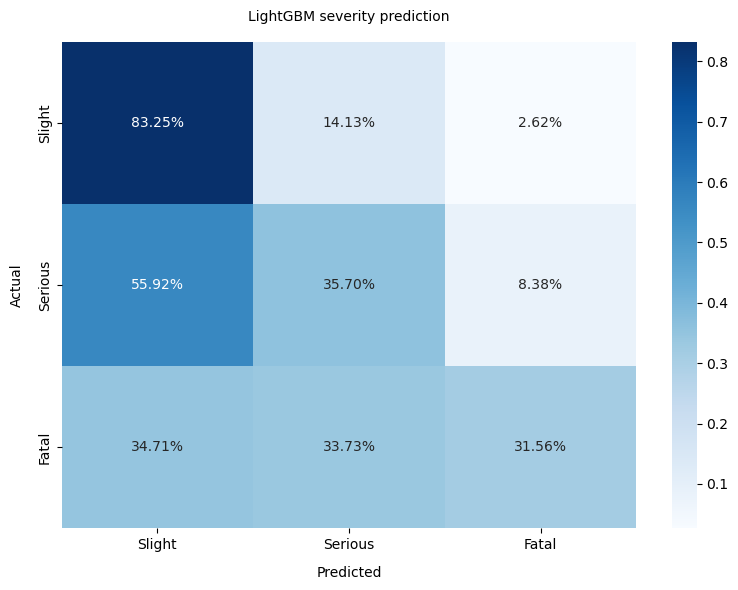

In [20]:
cm = confusion_matrix(y_test_sev, y_pred_lgb, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", cbar=True,
            xticklabels=['Slight', 'Serious', 'Fatal'],
            yticklabels=['Slight', 'Serious', 'Fatal'])
plt.title('LightGBM severity prediction', fontsize=10, pad=15)
plt.xlabel('Predicted', fontsize=10, labelpad=10)
plt.ylabel('Actual', fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

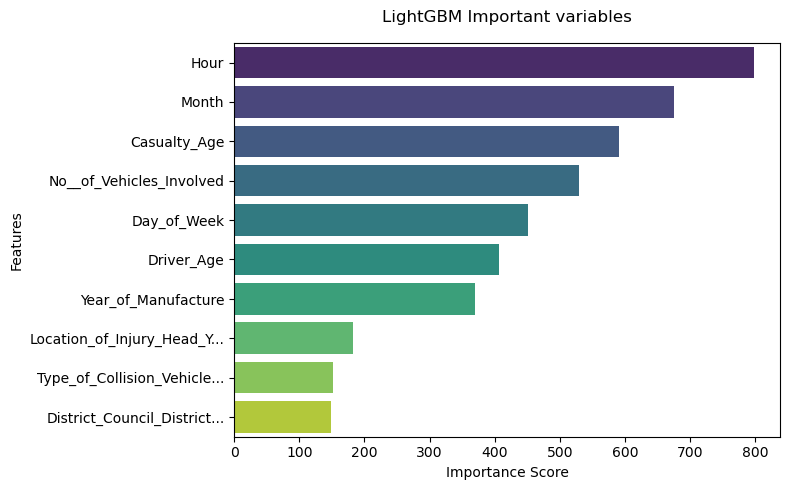

In [21]:
importances = lgb_model.feature_importances_
feature_names = X_train_sev.columns
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)
df_importance['Feature'] = df_importance['Feature'].apply(lambda x:x[:25]+'...' if len(str(x)) > 25 else x )

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis', hue='Feature', legend=False)
plt.title('LightGBM Important variables', fontsize=12, pad=15)
plt.xlabel('Importance Score', fontsize=10)
plt.ylabel('Features', fontsize=10)

plt.tight_layout()
plt.show()

# Modeling (Degree_of_Injury)

In [22]:
weight = {0 : 1, 1 : 5, 2 : 20}
lgb_model2 = LGBMClassifier(n_estimators=100, random_state=42, class_weight=weight, n_jobs=-1)
lgb_model2.fit(X_train_inj, y_train_inj)
y_pred_lgb2 = lgb_model2.predict(X_test_inj)
print(classification_report(y_test_inj, y_pred_lgb2))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006692 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 475
[LightGBM] [Info] Number of data points in the train set: 166659, number of used features: 107
[LightGBM] [Info] Start training from score -0.508124
[LightGBM] [Info] Start training from score -1.103842
[LightGBM] [Info] Start training from score -2.706320
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     37342
           1       0.28      0.40      0.33      4116
           2       0.28      0.48      0.35       207

    accuracy                           0.84     41665
   macro avg       0.50      0.59      0.53     41665
weighted avg       0.86      0.84      0.85     41665



# Mapping (Degree_of_Injury)

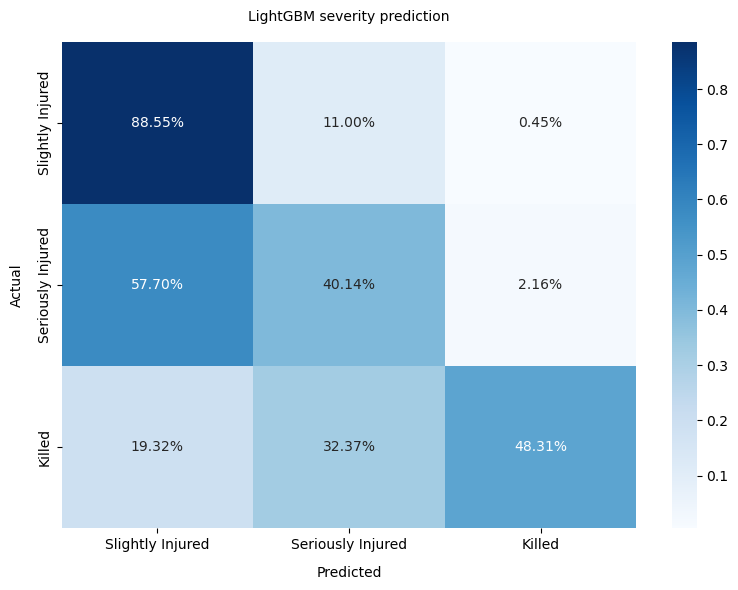

In [23]:
cm = confusion_matrix(y_test_inj, y_pred_lgb2, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", cbar=True,
            xticklabels=['Slightly Injured', 'Seriously Injured', 'Killed'],
            yticklabels=['Slightly Injured', 'Seriously Injured', 'Killed'])
plt.title('LightGBM severity prediction', fontsize=10, pad=15)
plt.xlabel('Predicted', fontsize=10, labelpad=10)
plt.ylabel('Actual', fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

# Modeling & Mapping (Number of injured)

In [27]:
reg_model = LGBMRegressor(objective='poisson', n_estimators=100, random_state=42, n_jobs=-1)
reg_model.fit(X_train_no_of_injured, y_train_no_of_injured)
y_pred_reg = reg_model.predict(X_test_no_of_injured)
mse = mean_squared_error(y_test_no_of_injured, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_no_of_injured, y_pred_reg)
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005992 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 473
[LightGBM] [Info] Number of data points in the train set: 166867, number of used features: 108
[LightGBM] [Info] Start training from score 0.919138
RMSE: 4.7518
R² Score: 0.2763


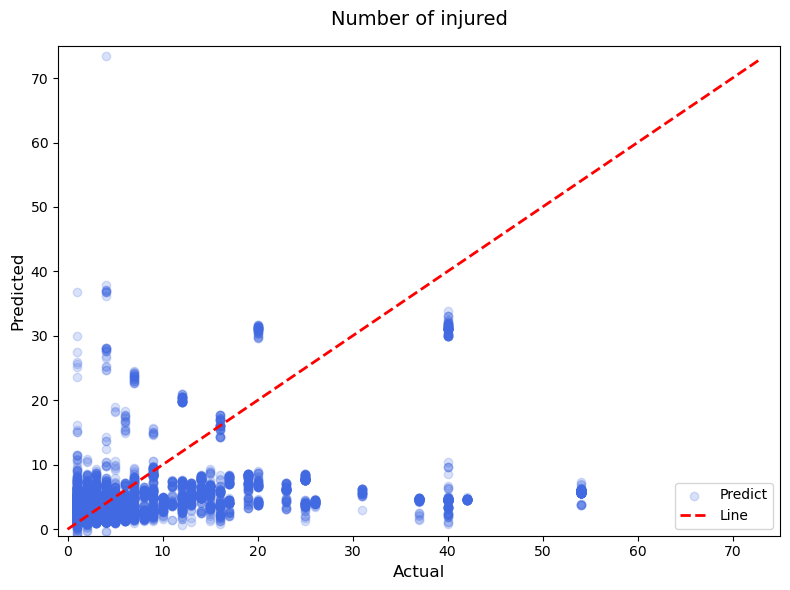

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_no_of_injured, y_pred_reg, alpha=0.2, color='royalblue', label='Predict')
max_val = int(max(y_test_no_of_injured.max(), y_pred_reg.max()))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Line')
plt.title('Number of injured', fontsize=14, pad=15)
plt.xlabel('Actual', fontsize=12)
plt.ylabel('Predicted', fontsize=12)
plt.xlim(-1, max_val + 2)
plt.ylim(-1, max_val + 2)
plt.legend()
plt.tight_layout()
plt.show()